# Probabilistic Influenza Forecasting with SIR-INN and MCMC

This notebook performs rolling-window Bayesian inference on Italian Influenza-like Illness (ILI) data
using a Physics-Informed Neural Network (SIR-INN) combined with MCMC.
Posterior samples are then propagated forward to generate probabilistic forecasts.

## From qualitative fit to probabilistic forecasting

In the previous notebook (`01_qualitative_fit_and_incidence.ipynb`), we performed a qualitative validation of the pretrained **SIR-INN** by comparing the reconstructed SIR trajectories and the derived ILI incidence with the observed training data.

In this notebook, we move beyond qualitative assessment and focus on **probabilistic forecasting**.  
Specifically, we leverage the pretrained SIR-INN within a **Bayesian inference framework** to estimate posterior distributions over the epidemiological parameters and to generate uncertainty-aware forecasts.

The main goals of this notebook are:
- to infer posterior distributions of the SIR parameters using MCMC,
- to propagate parameter uncertainty into future epidemic trajectories,
- to produce probabilistic forecasts of infectious dynamics and incidence.

## 1. Setup and environment

We load the required libraries and project modules.
The repository root is added to the Python path to enable local imports.

In [1]:
import sys
from pathlib import Path

# Add repository root to Python path
repo_root = Path().resolve().parent
sys.path.append(str(repo_root))

# Standard
import numpy as np
import torch
from torch import nn, load

# Project modules
from src.data.data_loader import load_multiple_influenza_seasons, plot_observed_ili_seasons
from src.models.sir_inn import NN
from src.forecasting.inference import run_influcast_mcmc_inference, load_mcmc_parameter_estimates, plot_mcmc_parameters
from src.forecasting.probabilistic_forecast import run_probabilistic_forecast_season, plot_probabilistic_forecasts_season

## 2. Data loading: Italian influenza seasons

We load weekly Italian ILI incidence data and define the epidemiological time axis.
The analysis is performed using epidemiological weeks.

In [2]:
## Epidemiological time indexing

# Define the time grids
domain = [0, 600]
times =  np.linspace(int(domain[0]), int(domain[1]), int(domain[1]) - int(domain[0]) + 1) 

# Epidemiological weeks of an influenza season (weeks 42–52, 01–17)
epi_weeks = np.array(list(range(42, 53)) + list(range(1, 18)))

# Continuous ordered time index (used by the model)
t_epi = np.arange(1, len(epi_weeks) + 1)

# String labels for plotting
epi_weeks_str = np.array([f"{w:02d}" for w in epi_weeks])

We first visualize the observed influenza-like illness (ILI) incidence
for the seasons under consideration. These trajectories will be used
as input data for parameter inference and probabilistic forecasting with SIR-INN.

In [3]:
seasons = load_multiple_influenza_seasons(
    seasons=["2023-2024", "2024-2025"]
)

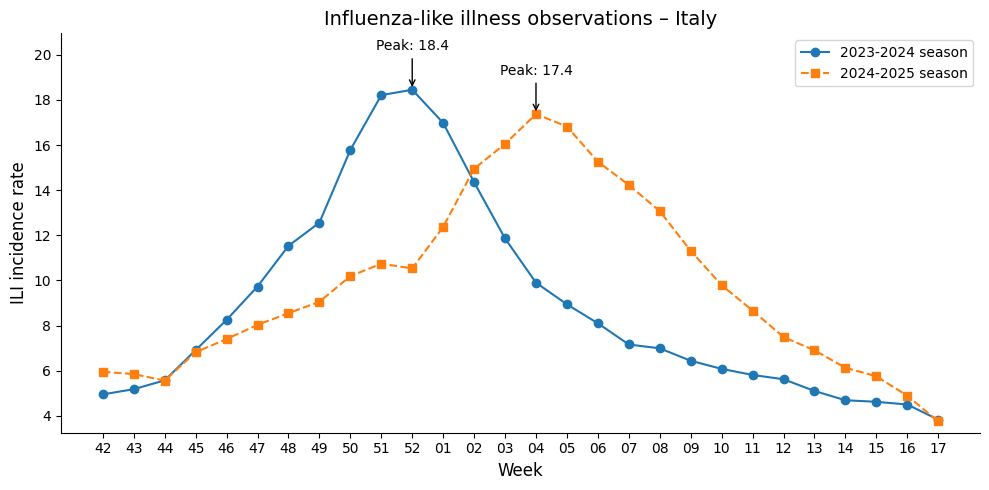

In [4]:
plot_observed_ili_seasons(seasons)

## 3. Parameter inference via rolling-window MCMC

We perform Bayesian parameter inference on the Influcast ILI observations using a rolling-window strategy.
At each epidemiological week, a short observation window is assimilated and a Markov Chain Monte Carlo (MCMC) procedure is employed to infer the epidemiological parameters of the SIR-INN model.

For each inference step (i.e., rolling window of length `observation_window_size`), we estimate the posterior distributions of the transmission rate $\beta$, the recovery rate $\gamma$, and the epidemic onset time $t_0$ (i.e., last observation used for the inference step).
The basic reproduction number $R_0 = \beta / \gamma$ is then derived from the inferred parameters.

In the following, we report the posterior mean estimates of these quantities as a function of time (i.e., week), providing insight into the temporal evolution and stability of the inferred epidemiological dynamics.

**Load the model and select one season of interest**

In [3]:
# The model approximates the continuous-time SIR dynamics
activation = nn.Tanh
dimensions = [3, 16, 32, 16, 3]
sir_inn = NN(activation=activation, dimensions=dimensions)
sir_inn.load_state_dict(torch.load("../checkpoints/SIR-INN_pretrained.pth", map_location='cpu'))

sir_inn.eval()

NN(
  (stack): Sequential(
    (0): Linear(in_features=3, out_features=16, bias=True)
    (1): Tanh()
    (2): Linear(in_features=16, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): Tanh()
    (6): Linear(in_features=16, out_features=3, bias=True)
    (7): Sigmoid()
  )
)

In [4]:
# Influenza season under study
season = '2023-2024'

# Length of rolling window of observations (weeks)
observation_window_size=5

# Folder of results
chains_dir = rf"../tmp_results/{season}" 

In [7]:
# Run rolling-window MCMC inference and save posterior chains
run_influcast_mcmc_inference(
    season=season,
    country="italia",
    t0_range=range(3, len(epi_weeks)),
    times=times,
    dt_train=observation_window_size,
    pinn_model=sir_inn,
    week_labels=epi_weeks_str,
    output_dir=chains_dir
)

MCMC rolling inference: 100%|███████████████████████████████████████████████████████████| 25/25 [04:10<00:00, 10.02s/it]


## 4. Inference visualization

We report the posterior mean estimates of the inferred quantities as a function of time (i.e., week)

In [5]:
t0_range = range(3, len(epi_weeks))

betas, gammas, t0s, R0s = load_mcmc_parameter_estimates(
    t0_range=t0_range,
    chains_dir=chains_dir,
    burnin=5000
)

betas_mean  = np.mean(betas)
gammas_mean = np.mean(gammas)
t0s_mean    = np.mean(t0s)
R0s_mean    = np.mean(R0s)

100%|█████████████████████████████████████████████████████████████████████████████████| 25/25 [00:00<00:00, 3153.99it/s]


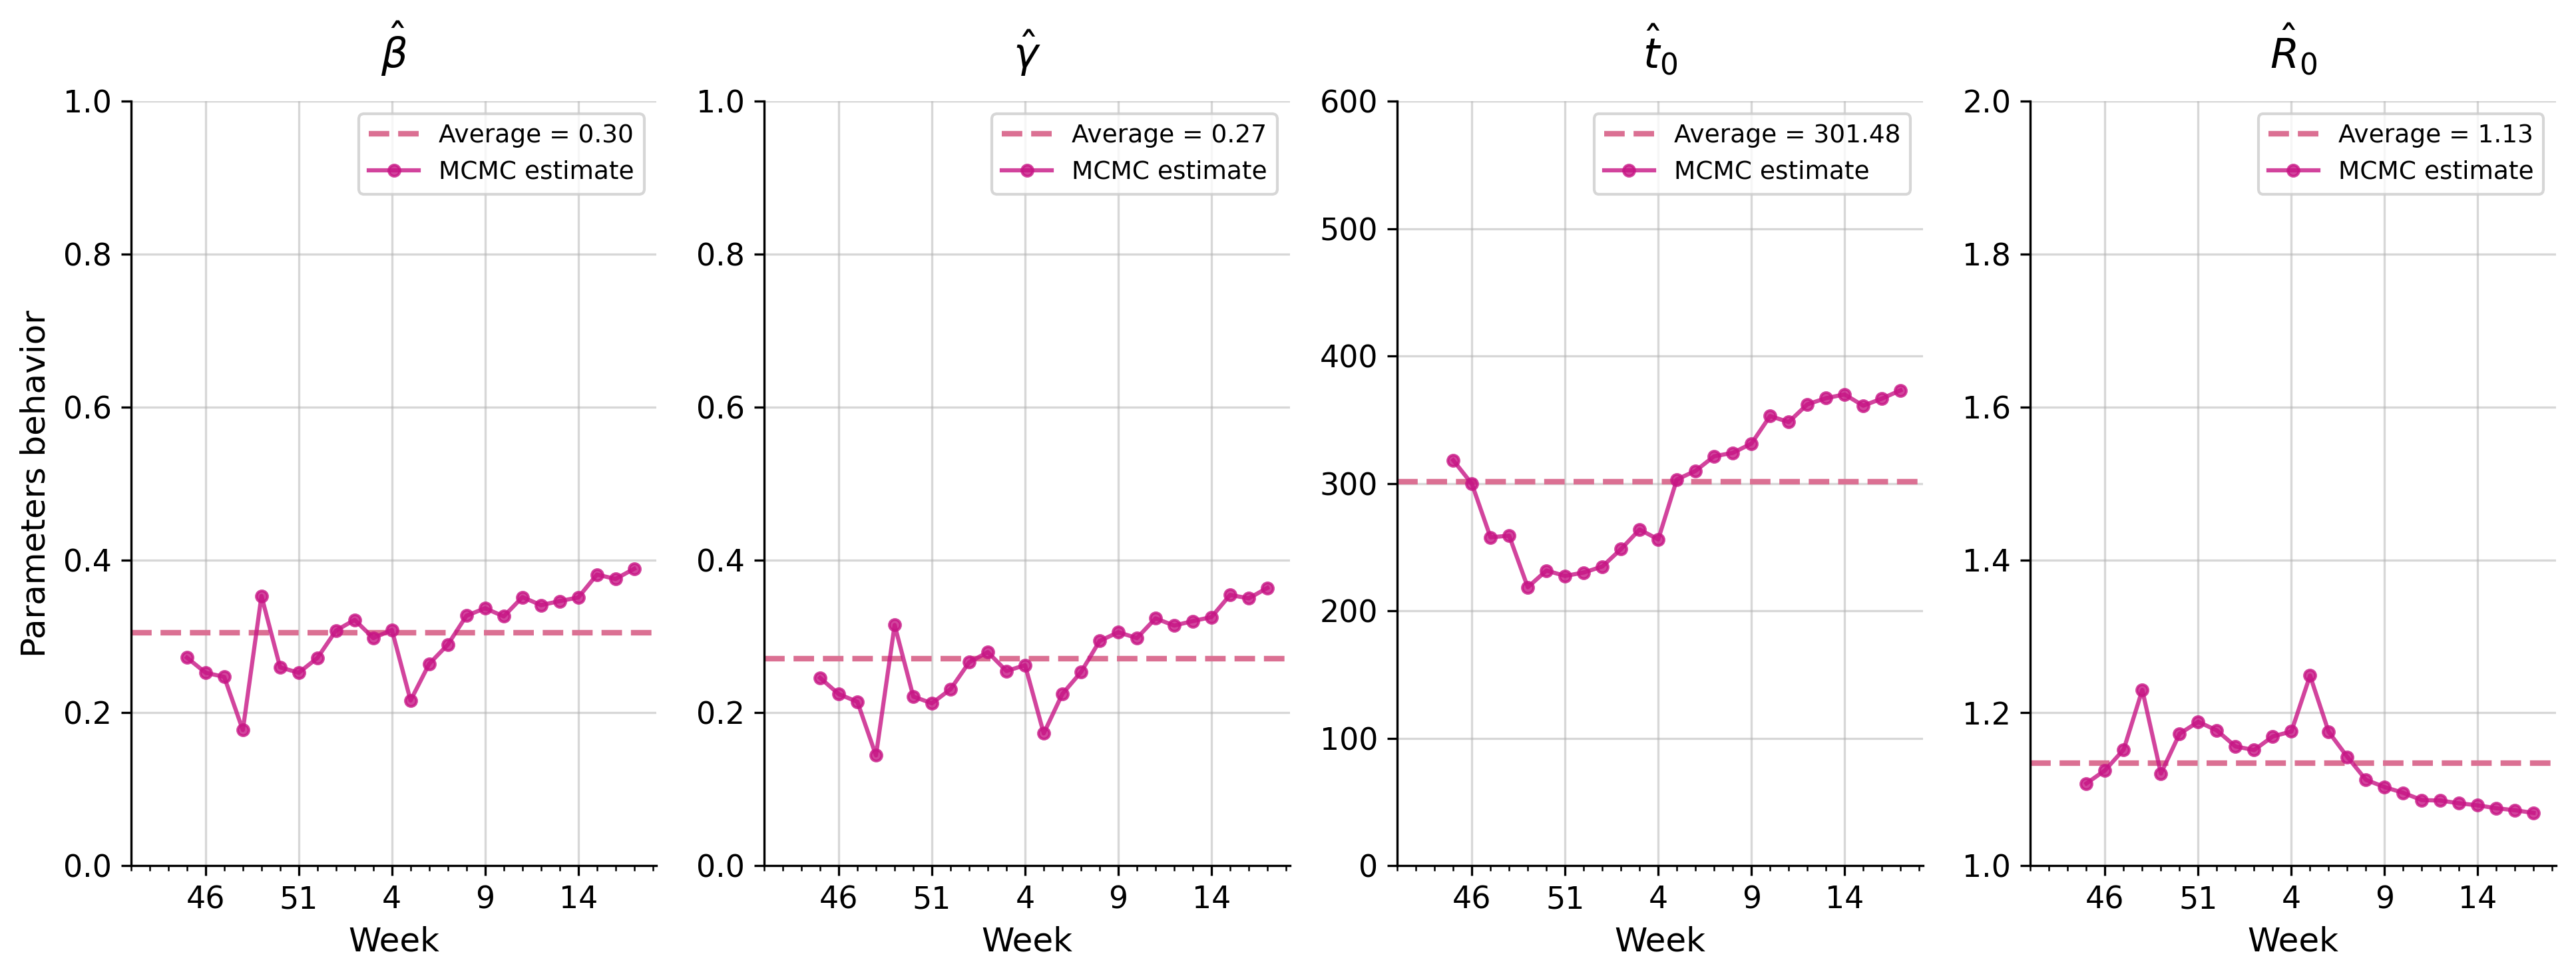

In [6]:
plot_mcmc_parameters(
    weeks_ordered=t_epi,
    weeks_labels=epi_weeks,
    betas=betas,
    gammas=gammas,
    t0s=t0s,
    R0s=R0s,
    betas_mean=betas_mean,
    gammas_mean=gammas_mean,
    t0s_mean=t0s_mean,
    R0s_mean=R0s_mean
)

## 5. Probabilistic forecasting

Posterior samples are propagated forward through the SIR-INN
to generate probabilistic forecasts.
Prediction intervals and quantiles are computed from the ensemble.

In [7]:
# Select how far you want to go in the future (weeks)
forecast_window_size = 10

# Generate probabilistic forecasts using posterior samples
forecasts = run_probabilistic_forecast_season(
    t0_range=range(3, len(epi_weeks)),
    chains_dir=chains_dir,
    dt_train=observation_window_size,
    dt_forecast=observation_window_size + forecast_window_size,
    pinn_model=sir_inn,
    dt=7,
    times=times,
    sample_strategy="random"
)

## 6. Short- and long-term forecasts visualization

For each time window of observations, we visualize the predictive mean
together with 50% and 90% prediction intervals.
Observed incidence is shown for reference.

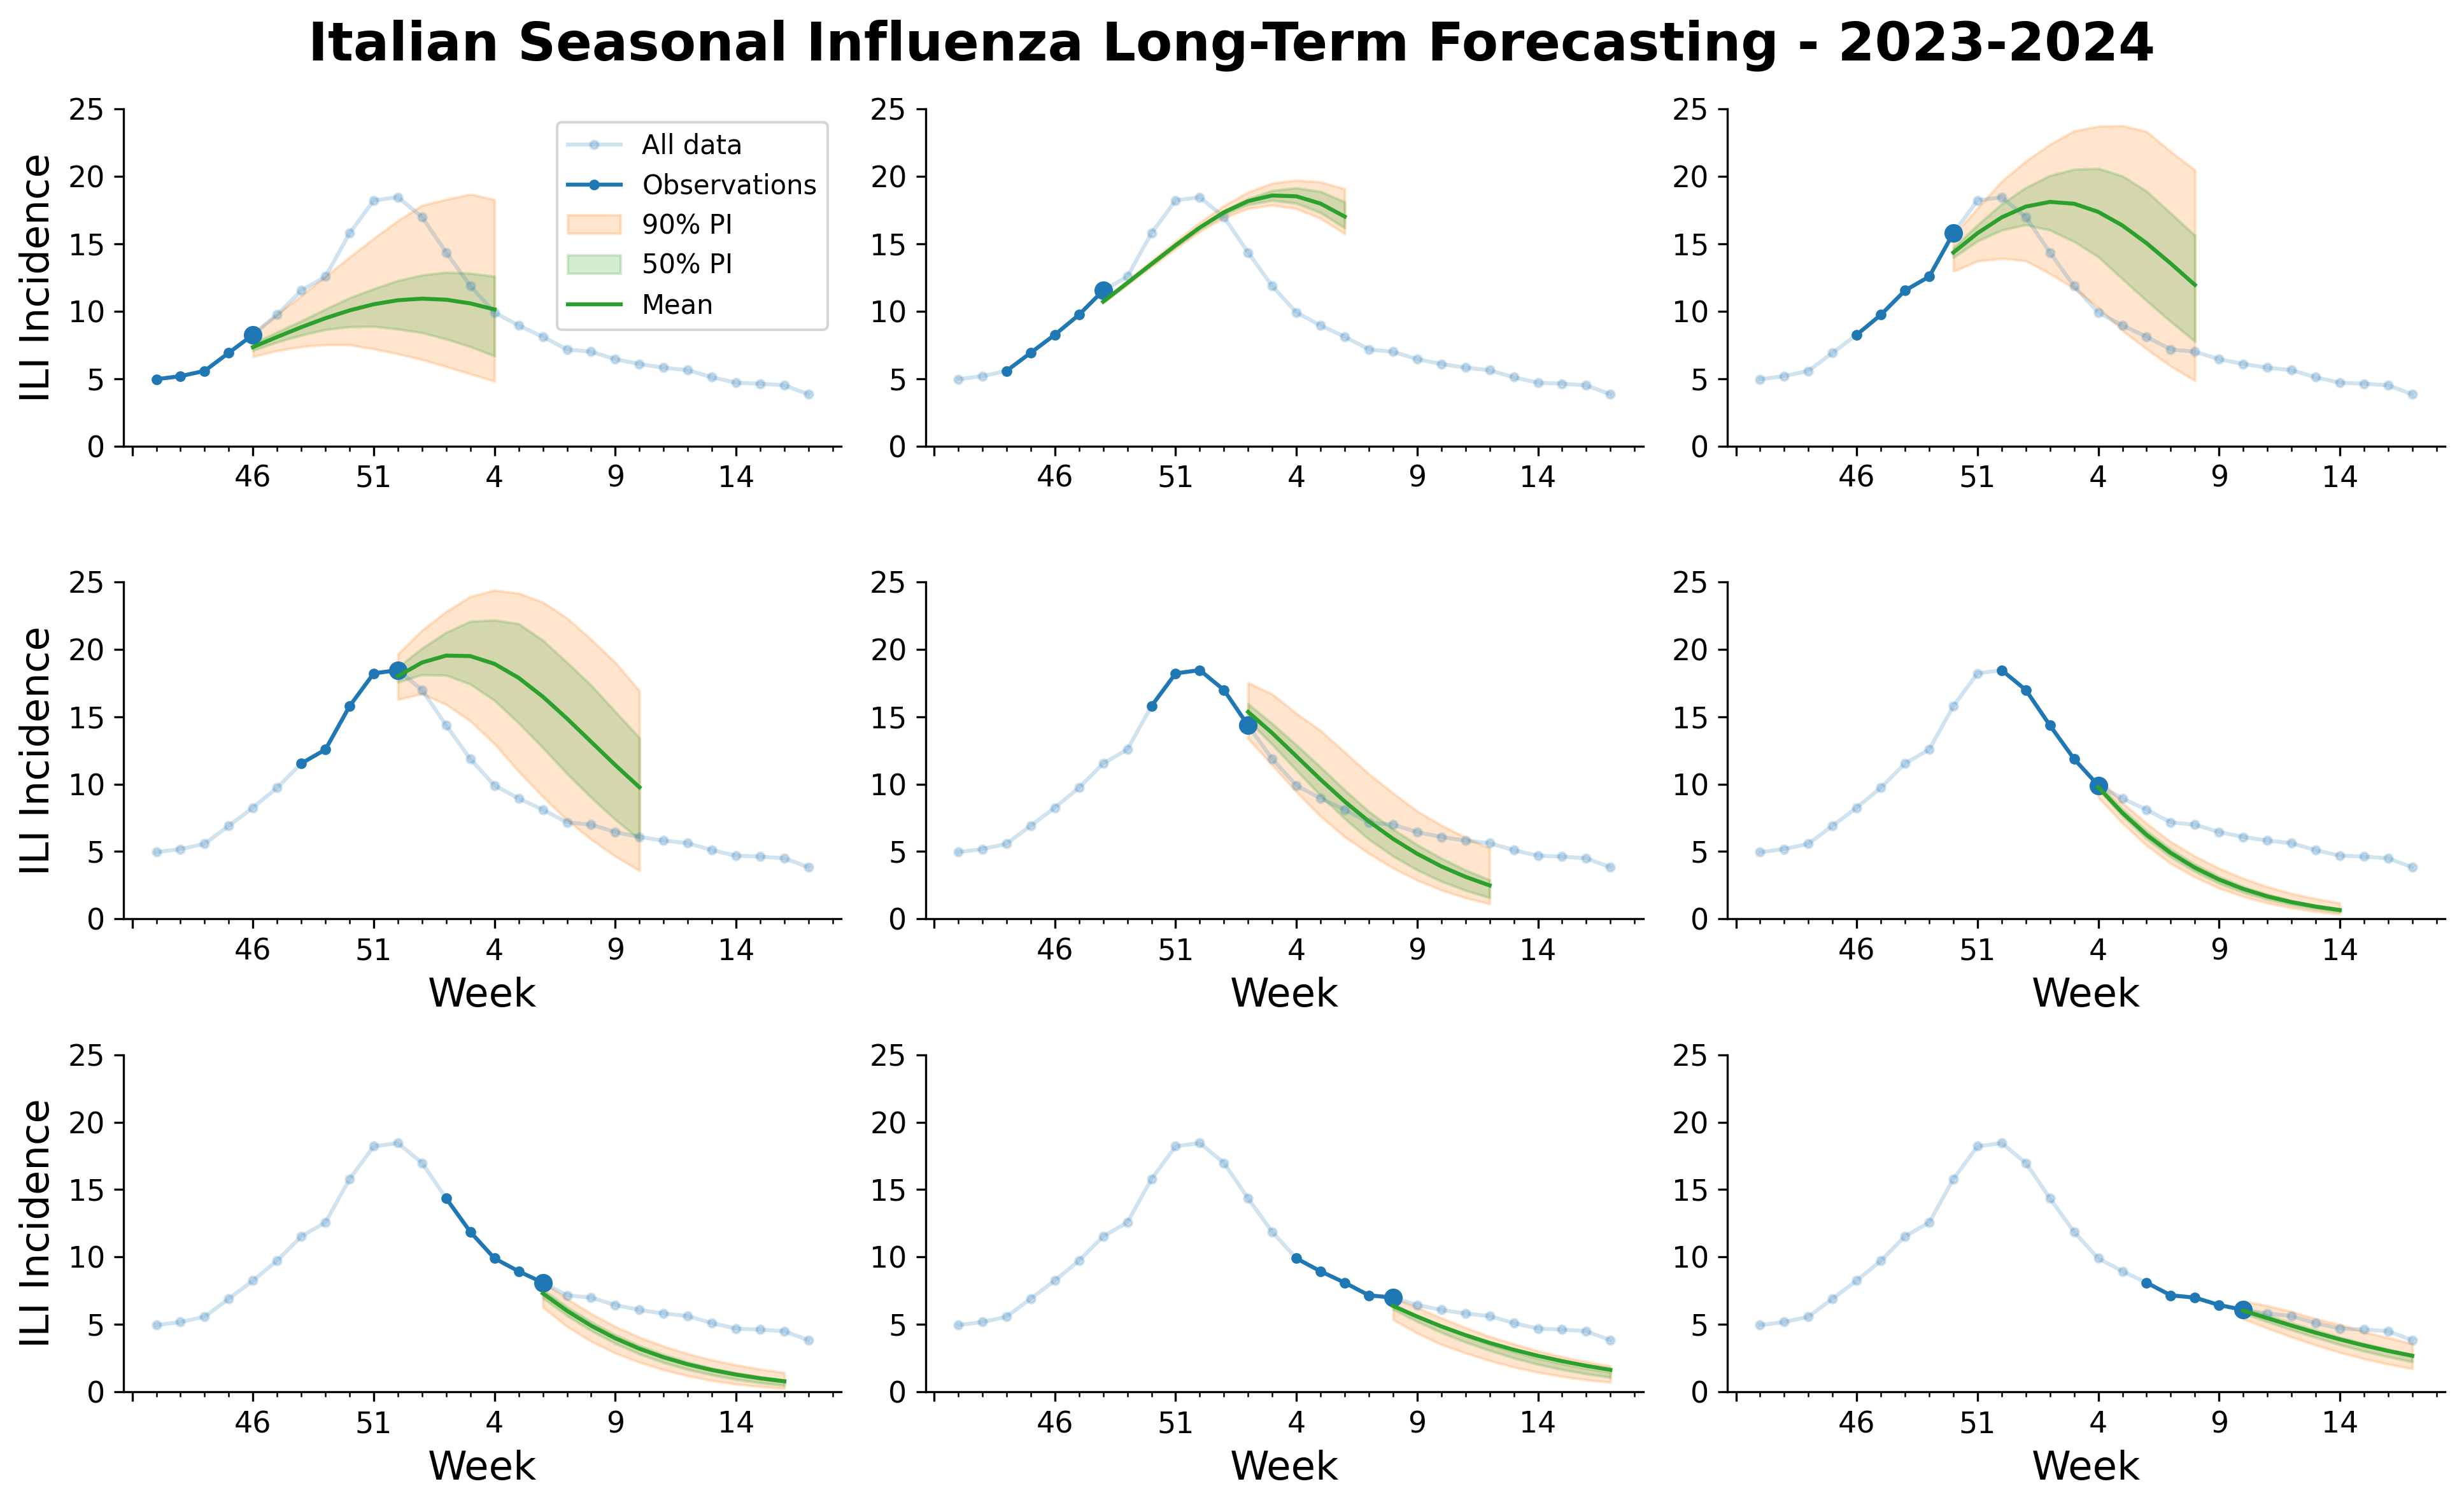

In [8]:
## Forecast visualization with prediction intervals
fig = plot_probabilistic_forecasts_season(
    forecasts=forecasts,
    season=season,
    dt_train=observation_window_size,
    t_epi=t_epi,
    epi_weeks=epi_weeks,
    error_width=90,
    error_width_1=50,
)